# Project REXIA

# Image data

## Imports et préliminaires

In [1]:
import os

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import lime
from lime import lime_image
import seaborn as sns

In [2]:
#import data
DATA_PATH = "./data/celeba-dataset"

In [3]:
df_attributes = pd.read_csv(os.path.join(DATA_PATH, "list_attr_celeba.csv"))
df_bbox = pd.read_csv(os.path.join(DATA_PATH, "list_bbox_celeba.csv"))
df_eval_partitions = pd.read_csv(os.path.join(DATA_PATH, "list_eval_partition.csv"))
df_landmarks = pd.read_csv(os.path.join(DATA_PATH, "list_landmarks_align_celeba.csv"))

## Analyse du jeu de données

### Analyse descriptive

Data Files

- img_align_celeba.zip: All the face images, cropped and aligned 
list_eval_partition.csv: Recommended partitioning of images into training, validation, testing sets. Images 1-162770 are training, 162771-182637 are validation, 182638-202599 are testing 
- list_bbox_celeba.csv: Bounding box information for each image. "x_1" and "y_1" represent the upper left point coordinate of bounding box. "width" and "height" represent the width and height of bounding box
- list_landmarks_align_celeba.csv: Image landmarks and their respective coordinates. There are 5 landmarks: left eye, right eye, nose, left mouth, right mouth 
- list_attr_celeba.csv: Attribute labels for each image. There are 40 attributes. "1" represents positive while "-1" represents negative

In [4]:
print(df_attributes.shape)  # 202599 pictures and 41 attributes (including the image name) 
display(df_attributes.head())              
print(f"List of attributes : {df_attributes.columns.tolist()}")            
print("----------------------------------")
print("Number of positives per attribute:") 
display((df_attributes == 1).sum())
print("----------------------------------")
print(f"Average number of positives accrosss all attributes: {(df_attributes == 1).mean() } ")

(202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


List of attributes : ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
----------------------------------
Number of positives per attribute:


image_id                    0
5_o_Clock_Shadow        22516
Arched_Eyebrows         54090
Attractive             103833
Bags_Under_Eyes         41446
Bald                     4547
Bangs                   30709
Big_Lips                48785
Big_Nose                47516
Black_Hair              48472
Blond_Hair              29983
Blurry                  10312
Brown_Hair              41572
Bushy_Eyebrows          28803
Chubby                  11663
Double_Chin              9459
Eyeglasses              13193
Goatee                  12716
Gray_Hair                8499
Heavy_Makeup            78390
High_Cheekbones         92189
Male                    84434
Mouth_Slightly_Open     97942
Mustache                 8417
Narrow_Eyes             23329
No_Beard               169158
Oval_Face               57567
Pale_Skin                8701
Pointy_Nose             56210
Receding_Hairline       16163
Rosy_Cheeks             13315
Sideburns               11449
Smiling                 97669
Straight_H

----------------------------------
Average number of positives accrosss all attributes: image_id               0.000000
5_o_Clock_Shadow       0.111136
Arched_Eyebrows        0.266981
Attractive             0.512505
Bags_Under_Eyes        0.204572
Bald                   0.022443
Bangs                  0.151575
Big_Lips               0.240796
Big_Nose               0.234532
Black_Hair             0.239251
Blond_Hair             0.147992
Blurry                 0.050899
Brown_Hair             0.205194
Bushy_Eyebrows         0.142168
Chubby                 0.057567
Double_Chin            0.046688
Eyeglasses             0.065119
Goatee                 0.062764
Gray_Hair              0.041950
Heavy_Makeup           0.386922
High_Cheekbones        0.455032
Male                   0.416754
Mouth_Slightly_Open    0.483428
Mustache               0.041545
Narrow_Eyes            0.115149
No_Beard               0.834940
Oval_Face              0.284143
Pale_Skin              0.042947
Pointy_Nose     

<Axes: ylabel='None'>

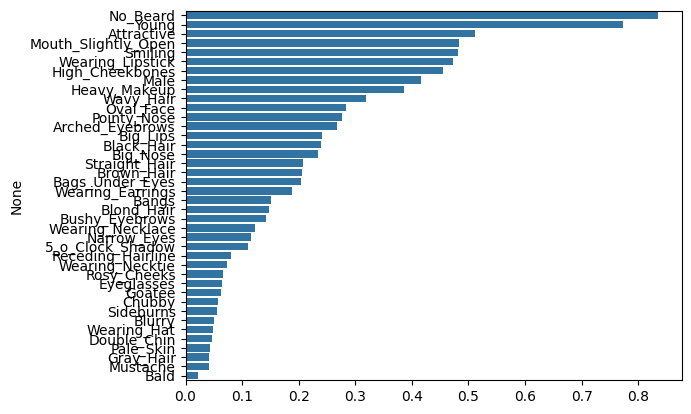

In [5]:
positive_rate = (df_attributes.drop('image_id', axis=1) == 1).mean().sort_values(ascending=False)
sns.barplot(x=positive_rate.values, y=positive_rate.index)

In [6]:
attr_cols = df_attributes.columns[1:]  # all columns except 'image_id'
df_eval_partitions['partition'].value_counts()    # 0=train, 1=val, 2=test
# puis merge avec les attributs pour vérifier que la distribution est homogène
merged = df_attributes.merge(df_eval_partitions, on='image_id')
merged.groupby('partition')[attr_cols].mean()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
partition,,,,,,,,,,,,,,,,,,,,,
0,-0.776654,-0.468231,0.027253,-0.591079,-0.954377,-0.696689,-0.518179,-0.528894,-0.521951,-0.701825,...,-0.887498,-0.040609,-0.582884,-0.361283,-0.626934,-0.901223,-0.060797,-0.757154,-0.853904,0.557879
1,-0.763930,-0.483163,0.040117,-0.585141,-0.958625,-0.706549,-0.693562,-0.502391,-0.582826,-0.692354,...,-0.862385,-0.033372,-0.588765,-0.446821,-0.618563,-0.905371,-0.108069,-0.758796,-0.854734,0.493129
2,-0.800220,-0.431119,-0.008316,-0.594730,-0.957619,-0.688508,-0.345957,-0.575994,-0.456768,-0.733494,...,-0.907224,0.000601,-0.580202,-0.271917,-0.586715,-0.915940,0.043783,-0.724176,-0.859834,0.514277


### Analyse des corrélations

<Axes: >

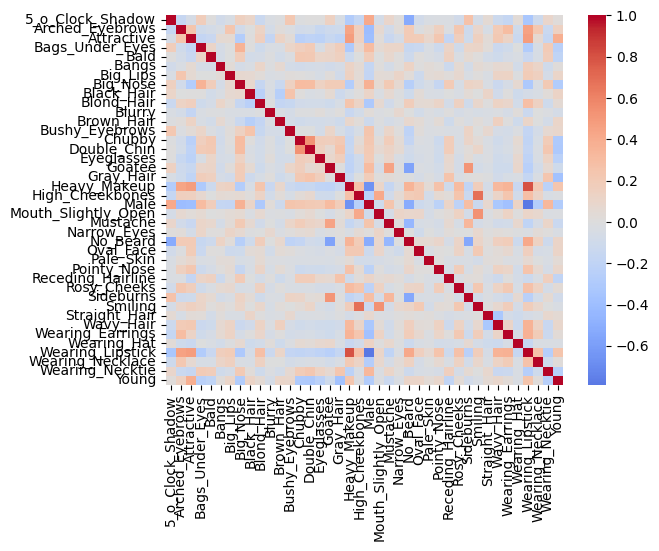

In [7]:
df_binary = (df_attributes[attr_cols] == 1).astype(int)
corr_matrix = df_binary.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True)

In [8]:
# Extraire le triangle supérieur sans la diagonale
corr_pairs = (corr_matrix
              .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .sort_values(ascending=False))

corr_pairs.head(15)   # plus corrélées positivement
corr_pairs.tail(15)   # plus corrélées négativement

Double_Chin       Young              -0.309809
Straight_Hair     Wavy_Hair          -0.321452
Male              Wavy_Hair          -0.323983
5_o_Clock_Shadow  Wearing_Lipstick   -0.333921
Gray_Hair         Young              -0.364466
Male              Wearing_Earrings   -0.373469
Attractive        Male               -0.394451
Arched_Eyebrows   Male               -0.408016
Mustache          No_Beard           -0.452595
Male              No_Beard           -0.522243
5_o_Clock_Shadow  No_Beard           -0.526946
No_Beard          Sideburns          -0.543061
Goatee            No_Beard           -0.570071
Heavy_Makeup      Male               -0.666724
Male              Wearing_Lipstick   -0.789435
dtype: float64

#### Corrélations artificielles

Deux variables sont artificiellement corrélées quand leur forte corrélation statistique entre deux variables qui n'ont pas de lien causal directs mais résulte d'un troisième facteur.

**Wearing_Lipstick <-> Male** : forte corrélation négative, mais causée par le genre comme variable confondante - ce n'est pas que le rouge à lèvres cause d'être femme, c'est que les deux co-occurrent dans les données de collecte.

**Heavy_Makeup <-> Attractive** : corrélées positivement, mais le lien est biaisé par les standards de beauté présents dans les annotations humaines.

<Axes: >

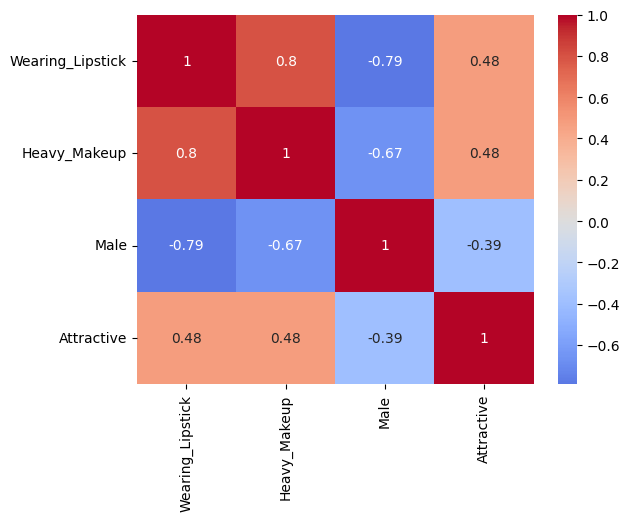

In [9]:
# tableau croisé
pd.crosstab(df_binary['Wearing_Lipstick'], df_binary['Male'], normalize='index')
# ou un heatmap de la sous-matrice
sns.heatmap(df_binary[['Wearing_Lipstick', 'Heavy_Makeup', 'Male', 'Attractive']].corr(),
            annot=True, cmap='coolwarm', center=0)

### Identification de variables sensibles

La justification de la sensibilité d'une variable repose sur trois critères : **caractéristique protégée** (genre, couleur de peau, âge = protégés par la loi en France/UE), **risque de discrimination** si utilisée dans un modèle, et **déséquilibre de représentation**. Par exemple Pale_Skin n'est pas directement un attribut légalement protégé mais il est un proxy de l'origine ethnique - ce qui le rend sensible.

In [10]:
sensitive = ['Male', 'Pale_Skin', 'Young']
(df_binary[sensitive] == 1).mean()   # taux de présence dans le dataset

Male         0.416754
Pale_Skin    0.042947
Young        0.773617
dtype: float64

### Analyse de disparité

Pale_Skin,0,1
Male,,
0,0.550447,0.032799
1,0.406606,0.010148


<Axes: >

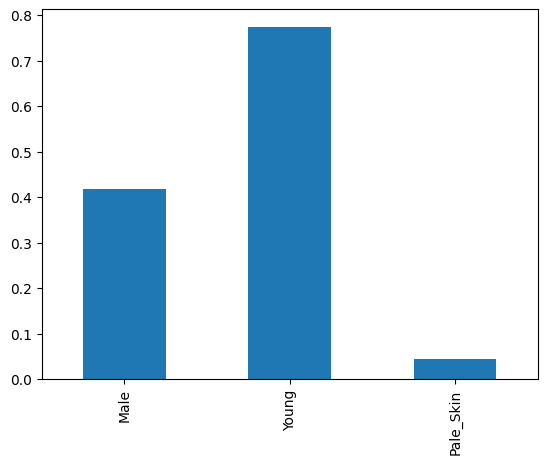

In [11]:
# Distribution de Male
df_binary['Male'].value_counts(normalize=True)

# Croisement de deux attributs sensibles
display(pd.crosstab(df_binary['Male'], df_binary['Pale_Skin'], normalize='all'))

# Pour visualiser plusieurs groupes simultanément
group_cols = ['Male', 'Young', 'Pale_Skin']
df_binary[group_cols].mean().plot(kind='bar')

biais de représentativité : 55% de femmes à la peau pâle.

In [12]:
# Combinaisons rares
df_binary.groupby(['Male', 'Pale_Skin', 'Young']).size().sort_values()

Male  Pale_Skin  Young
1     1          0          483
0     1          0          739
1     1          1         1573
0     1          1         5906
      0          0        14139
1     0          0        30504
                 1        51874
0     0          1        97381
dtype: int64

### Analyse de la fairness

In [13]:
def fairness_metrics(df, sensitive_attr, target_attr):
    groups = df.groupby(sensitive_attr)[target_attr].mean()
    # groups[1]  = P(Y=1 | S=1)
    # groups[0]  = P(Y=1 | S=-1)  (on a converti -1 → 0 avant)
    
    p_s1 = groups[1]
    p_s0 = groups[0]
    
    demographic_parity = abs(p_s1 - p_s0)
    disparate_impact   = p_s1 / p_s0 if p_s0 > 0 else np.nan
    
    return {'demographic_parity': demographic_parity,
            'disparate_impact': disparate_impact}

## Apprentissage automatique

## Explications post-hoc

> Lime Shapley

In [ ]:
import cv2
import numpy as np
import pandas as pd
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

PHYSICAL_PARTS = ["lefteye", "righteye", "nose", "leftmouth", "rightmouth"]

class LandmarkExtractor:
    RESULT_SIZE = 64

    def __init__(self, df_landmarks: pd.DataFrame, n_workers: int = 8):
        self.df_landmarks = df_landmarks.set_index('image_id')  # index for O(1) lookups
        self.n_workers = n_workers

    def show_image(self, image: np.ndarray, landmarks: pd.Series = None):
        image_tmp = image.copy()
        if landmarks is not None:
            for part in PHYSICAL_PARTS:
                x = landmarks[f"{part}_x"]
                y = landmarks[f"{part}_y"]
                cv2.circle(image_tmp, (x, y), 3, (0, 0, 255), -1)
        plt.imshow(image_tmp)
        plt.axis('off')
        plt.show()

    def get_croped_image(self, image_id: int, margin: float = 0.2, plot_images: bool = False):
        img_name = f"{image_id:06d}.jpg"
        landmark = self.__get_landmark(img_name)
        image = self.__load_image(img_name)

        if plot_images:
            self.show_image(image, landmark)

        rotation, center, final_src_size = self.get_lips_rotation(landmark, margin)
        rotated_image = cv2.warpAffine(image, rotation, (image.shape[1], image.shape[0]))

        x, y = int(center[0]), int(center[1])
        half_size = int(final_src_size / 2)
        cropped_image = rotated_image[
            max(0, y - half_size):min(rotated_image.shape[0], y + half_size),
            max(0, x - half_size):min(rotated_image.shape[1], x + half_size)
        ]

        final_image = cv2.resize(cropped_image, (self.RESULT_SIZE, self.RESULT_SIZE))

        if plot_images:
            self.show_image(final_image)

        return final_image

    def __get_landmark(self, image_name: str) -> pd.Series:
        try:
            return self.df_landmarks.loc[image_name]
        except KeyError:
            raise ValueError(f"Image {image_name} not found in landmarks dataframe.")

    def __load_image(self, image_name: str) -> np.ndarray:
        image = cv2.imread(os.path.join(DATA_PATH, "img_align_celeba/img_align_celeba", image_name))
        if image is None:
            raise ValueError(f"Image {image_name} not found.")
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def get_lips_rotation(self, landmark: pd.Series, margin: float = 0.2):
        leftmouth_x, leftmouth_y   = landmark['leftmouth_x'],  landmark['leftmouth_y']
        rightmouth_x, rightmouth_y = landmark['rightmouth_x'], landmark['rightmouth_y']
        nose_x, nose_y             = landmark['nose_x'],       landmark['nose_y']

        center_x = (leftmouth_x + rightmouth_x) / 2
        center_y = (leftmouth_y + rightmouth_y) / 2

        dist_leftmouth  = np.linalg.norm([leftmouth_x  - center_x, leftmouth_y  - center_y])
        dist_rightmouth = np.linalg.norm([rightmouth_x - center_x, rightmouth_y - center_y])
        dist_nose       = np.linalg.norm([nose_x       - center_x, nose_y       - center_y])

        final_src_size = 2 * max(dist_leftmouth, dist_rightmouth, dist_nose) * (1 + margin)

        dx = rightmouth_x - leftmouth_x
        dy = rightmouth_y - leftmouth_y
        angle = np.degrees(np.arctan2(dy, dx))

        rotation_matrix = cv2.getRotationMatrix2D((center_x, center_y), angle, 1.0)
        return rotation_matrix, (center_x, center_y), final_src_size

    def process_and_save(self, image_id: int, output_dir: str, margin: float = 0.2) -> tuple[int, bool]:
        """Process a single image and save it. Returns (image_id, success)."""
        output_path = os.path.join(output_dir, f"{image_id:06d}.jpg")
        if os.path.exists(output_path):  # skip already processed
            return image_id, True
        try:
            cropped = self.get_croped_image(image_id, margin=margin)
            cv2.imwrite(output_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
            return image_id, True
        except Exception as e:
            print(f"[WARN] image_id={image_id}: {e}")
            return image_id, False


def process_all_images(
    extractor: LandmarkExtractor,
    img_ids: list[int],
    output_dir: str = "croped",
    margin: float = 0.2,
) -> list[int]:
    """
    Process all images in img_ids, save crops to output_dir.
    Returns a list of failed image ids.
    """
    os.makedirs(output_dir, exist_ok=True)
    failed = []

    with ThreadPoolExecutor(max_workers=extractor.n_workers) as executor:
        futures = {
            executor.submit(extractor.process_and_save, img_id, output_dir, margin): img_id
            for img_id in img_ids
        }
        for future in tqdm(as_completed(futures), total=len(futures), desc="Cropping images"):
            img_id, success = future.result()
            if not success:
                failed.append(img_id)

    print(f"Done. {len(img_ids) - len(failed)}/{len(img_ids)} images saved to '{output_dir}/'.")
    if failed:
        print(f"Failed image ids: {failed}")
    return failed


# Usage
extractor = LandmarkExtractor(df_landmarks, n_workers=8)
img_ids = range(202600)
failed_ids = process_all_images(extractor, img_ids, output_dir="data/celeba-dataset/img-celeba-mouth")

[WARN] image_id=0: Image 000000.jpg not found in landmarks dataframe.


Cropping images: 100%|██████████| 202600/202600 [00:07<00:00, 27872.91it/s]


Done. 202599/202600 images saved to 'data/celeba-dataset/img-celeba-mouth/'.
Failed image ids: [0]


In [14]:
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms
import torch
import cv2

def get_transforms(partition: int) -> transforms.Compose:
    """Train partition (0) gets augmentation, val/test get only normalization."""
    normalize = transforms.Compose([
        transforms.ToTensor(),                          # HWC uint8 → CHW float [0,1]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    if partition == 0:
        return transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            normalize,
        ])
    return normalize


class CelebASmilingDataset(Dataset):
    def __init__(
        self,
        df_attributes: pd.DataFrame,
        df_eval_partitions: pd.DataFrame,
        partition: int = 0,
        img_dir: str = "data/celeba-dataset/img-celeba-mouth",
        transform: transforms.Compose = None,
    ):
        merged = (
            df_attributes[["image_id", "Smiling"]]
            .merge(df_eval_partitions, on="image_id")
        )
        self.data      = merged[merged["partition"] == partition].reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform if transform is not None else get_transforms(partition)

        # Pre-compute image ids once — avoids repeated string slicing in __getitem__
        self.image_ids = (
            self.data["image_id"].str.removesuffix(".jpg").astype(int).to_numpy()
        )
        # Pre-compute labels as a tensor — no per-sample conversion overhead
        self.labels = torch.tensor(
            self.data["Smiling"].to_numpy(), dtype=torch.float32
        )
        # Note: labels are in {-1, 1} in the original dataset; we can convert to {0, 1} if desired:
        self.labels = (self.labels + 1) / 2

    def __len__(self) -> int:
        return len(self.data)

    def __load_image(self, image_id: int) -> np.ndarray:
        img_path = os.path.join(self.img_dir, f"{image_id:06d}.jpg")
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found: {img_path}")
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        image  = self.__load_image(self.image_ids[idx])
        label  = self.labels[idx]
        return self.transform(image), label


In [15]:
train_dataset = CelebASmilingDataset(df_attributes, df_eval_partitions, partition=0)
val_dataset = CelebASmilingDataset(df_attributes, df_eval_partitions, partition=1)
test_dataset = CelebASmilingDataset(df_attributes, df_eval_partitions, partition=2)

print("Length of train dataset:", len(train_dataset))
print("Length of val dataset:", len(val_dataset))
print("Length of test dataset:", len(test_dataset))

Length of train dataset: 162770
Length of val dataset: 19867
Length of test dataset: 19962


In [16]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Batch of images shape: torch.Size([64, 3, 64, 64])
Batch of labels shape: torch.Size([64])


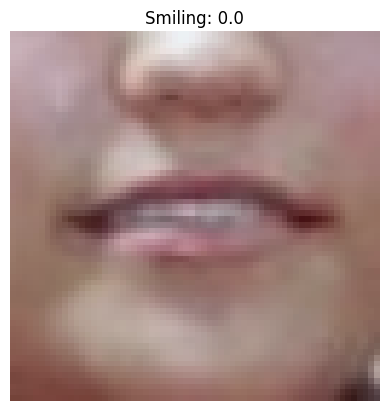

In [36]:
for images, labels in train_dataloader:
    print("Batch of images shape:", images.shape)
    print("Batch of labels shape:", labels.shape)
    # Plot the first image in the batch
    plt.imshow(images[0].permute(1, 2, 0).numpy() * 0.229 + 0.485)  # unnormalize for visualization
    plt.title(f"Smiling: {labels[0].item()}")
    plt.axis('off')
    plt.show()
    break

In [18]:
%load_ext autoreload
%autoreload 2
%aimport -google.protobuf
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import numpy as np
from tqdm import tqdm

def get_mobilenet(freeze_backbone: bool = True) -> nn.Module:
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
    model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, 1)
    return model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import mlflow
import mlflow.pytorch

def compute_metrics(all_labels: np.ndarray, all_preds: np.ndarray, all_probs: np.ndarray) -> dict:
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy":    (tp + tn) / (tp + tn + fp + fn),
        "precision":   tp / (tp + fp + 1e-8),
        "recall":      tp / (tp + fn + 1e-8),
        "f1":          f1_score(all_labels, all_preds),
        "auc_roc":     roc_auc_score(all_labels, all_probs),
        "specificity": tn / (tn + fp + 1e-8),
    }

def print_metrics(metrics: dict, loss: float, phase: str, epoch: int) -> None:
    print(
        f"[{phase}] Epoch {epoch:02d} | Loss {loss:.4f} | "
        f"Acc {metrics['accuracy']:.3f} | F1 {metrics['f1']:.3f} | "
        f"AUC {metrics['auc_roc']:.3f} | Prec {metrics['precision']:.3f} | "
        f"Rec {metrics['recall']:.3f} | Spec {metrics['specificity']:.3f}"
    )

# ── One epoch ─────────────────────────────────────────────────────────────────

def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None,
    device: torch.device,
    phase: str,
    epoch: int,
    global_step: int,                   # tracks absolute batch count across epochs
) -> tuple[float, dict, int]:
    is_train = phase == "train"
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    # Running counts for step-level metrics without storing all history
    run_tp = run_tn = run_fp = run_fn = 0

    with torch.set_grad_enabled(is_train):
        bar = tqdm(loader, desc=f"{phase} epoch {epoch}", leave=False)
        for images, labels in bar:
            images    = images.to(device)
            labels_01 = ((labels + 1) / 2).float().to(device)

            logits = model(images).squeeze(1)
            loss   = criterion(logits, labels_01)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits).cpu().detach().numpy()
            preds = (probs >= 0.5).astype(int)
            labs  = labels_01.cpu().numpy().astype(int)

            # Accumulate for epoch-level metrics
            total_loss += loss.item() * len(labels)
            all_labels.extend(labs)
            all_preds.extend(preds)
            all_probs.extend(probs)

            # ── Running confusion matrix for step-level metrics ────────────
            cm = confusion_matrix(labs, preds, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            run_tn += tn; run_fp += fp; run_fn += fn; run_tp += tp

            step_loss     = loss.item()
            step_acc      = (run_tp + run_tn) / (run_tp + run_tn + run_fp + run_fn)
            step_precision = run_tp / (run_tp + run_fp + 1e-8)
            step_recall   = run_tp / (run_tp + run_fn + 1e-8)
            step_f1       = 2 * step_precision * step_recall / (step_precision + step_recall + 1e-8)
            step_spec     = run_tn / (run_tn + run_fp + 1e-8)

            # ── Log step-level metrics to MLflow ──────────────────────────
            mlflow.log_metrics({
                f"{phase}/step_loss":      step_loss,
                f"{phase}/step_accuracy":  step_acc,
                f"{phase}/step_precision": step_precision,
                f"{phase}/step_recall":    step_recall,
                f"{phase}/step_f1":        step_f1,
                f"{phase}/step_spec":      step_spec,
            }, step=global_step)

            global_step += 1
            bar.set_postfix({"loss": f"{step_loss:.4f}", "acc": f"{step_acc:.3f}", "f1": f"{step_f1:.3f}"})

    # ── Epoch-level metrics ────────────────────────────────────────────────
    avg_loss = total_loss / len(loader.dataset)
    metrics  = compute_metrics(np.array(all_labels), np.array(all_preds), np.array(all_probs))
    print_metrics(metrics, avg_loss, phase.capitalize(), epoch)

    mlflow.log_metrics({
        f"{phase}/epoch_loss":        avg_loss,
        f"{phase}/epoch_accuracy":    metrics["accuracy"],
        f"{phase}/epoch_f1":          metrics["f1"],
        f"{phase}/epoch_auc_roc":     metrics["auc_roc"],
        f"{phase}/epoch_precision":   metrics["precision"],
        f"{phase}/epoch_recall":      metrics["recall"],
        f"{phase}/epoch_specificity": metrics["specificity"],
    }, step=epoch)

    return avg_loss, metrics, global_step

# ── Training loop ─────────────────────────────────────────────────────────────

def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    n_epochs: int = 20,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 5,
    freeze_backbone: bool = True,
    run_name: str = None,
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
) -> dict:
    model.to(device)

    pos_weight = torch.tensor([0.3], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    with mlflow.start_run(run_name=run_name):

        # ── Log hyperparameters ───────────────────────────────────────────
        mlflow.log_params({
            "n_epochs":        n_epochs,
            "lr":              lr,
            "weight_decay":    weight_decay,
            "patience":        patience,
            "freeze_backbone": freeze_backbone,
            "optimizer":       "AdamW",
            "scheduler":       "CosineAnnealingLR",
            "model":           "MobileNetV3-Small",
        })

        history      = {"train": [], "val": []}
        best_val_auc = -1.0
        best_weights = None
        epochs_no_imp = 0
        global_step  = 0   # shared counter across all train batches

        for epoch in range(1, n_epochs + 1):
            train_loss, train_metrics, global_step = run_epoch(
                model, train_loader, criterion, optimizer, device, "train", epoch, global_step
            )
            val_loss, val_metrics, _ = run_epoch(
                model, val_loader, criterion, None, device, "val", epoch, global_step=0
            )
            scheduler.step()

            # Log current learning rate
            mlflow.log_metric("train/lr", scheduler.get_last_lr()[0], step=epoch)

            history["train"].append({"loss": train_loss, **train_metrics})
            history["val"].append(  {"loss": val_loss,   **val_metrics})

            # ── Early stopping ────────────────────────────────────────────
            if val_metrics["auc_roc"] > best_val_auc:
                best_val_auc  = val_metrics["auc_roc"]
                best_weights  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_imp = 0
                mlflow.log_metric("val/best_auc", best_val_auc, step=epoch)
                print(f"  ✓ New best val AUC: {best_val_auc:.4f} — weights saved.")
            else:
                epochs_no_imp += 1
                print(f"  No improvement for {epochs_no_imp}/{patience} epochs.")
                if epochs_no_imp >= patience:
                    print(f"Early stopping at epoch {epoch}.")
                    mlflow.set_tag("early_stopped", f"epoch_{epoch}")
                    break

            print()

        # ── Test evaluation ───────────────────────────────────────────────
        model.load_state_dict(best_weights)
        print("=" * 70)
        print("FINAL EVALUATION ON TEST SET")
        print("=" * 70)
        test_loss, test_metrics, _ = run_epoch(
            model, test_loader, criterion, None, device, "test", epoch=0, global_step=0
        )

        mlflow.log_metrics({
            "test/loss":        test_loss,
            "test/accuracy":    test_metrics["accuracy"],
            "test/f1":          test_metrics["f1"],
            "test/auc_roc":     test_metrics["auc_roc"],
            "test/precision":   test_metrics["precision"],
            "test/recall":      test_metrics["recall"],
            "test/specificity": test_metrics["specificity"],
        })

        # Log the best model weights
        mlflow.pytorch.log_model(model, artifact_path="model")

    return {"history": history, "test_loss": test_loss, "test_metrics": test_metrics}


# ── Entry point ───────────────────────────────────────────────────────────────
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("celeba-smiling")

model   = get_mobilenet(freeze_backbone=True)
results = train(
    model, train_dataloader, val_dataloader, test_dataloader,
    n_epochs=5, lr=1e-3, patience=3, run_name="mobilenetv3-baseline"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[Train] Epoch 01 | Loss 0.2731 | Acc 0.799 | F1 0.779 | AUC 0.872 | Prec 0.826 | Rec 0.737 | Spec 0.857


[Val] Epoch 01 | Loss 0.2611 | Acc 0.827 | F1 0.811 | AUC 0.900 | Prec 0.860 | Rec 0.767 | Spec 0.883
  ✓ New best val AUC: 0.8995 — weights saved.



[Train] Epoch 02 | Loss 0.2660 | Acc 0.818 | F1 0.798 | AUC 0.890 | Prec 0.853 | Rec 0.749 | Spec 0.881


[Val] Epoch 02 | Loss 0.2618 | Acc 0.826 | F1 0.819 | AUC 0.905 | Prec 0.823 | Rec 0.815 | Spec 0.836
  ✓ New best val AUC: 0.9045 — weights saved.



...

[Train] Epoch 05 | Loss 0.2593 | Acc 0.834 | F1 0.816 | AUC 0.908 | Prec 0.869 | Rec 0.769 | Spec 0.893


[Val] Epoch 05 | Loss 0.2553 | Acc 0.841 | F1 0.829 | AUC 0.915 | Prec 0.865 | Rec 0.795 | Spec 0.884
  ✓ New best val AUC: 0.9149 — weights saved.

FINAL EVALUATION ON TEST SET


2026/03/22 15:29:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[Test] Epoch 00 | Loss 0.2489 | Acc 0.842 | F1 0.835 | AUC 0.916 | Prec 0.876 | Rec 0.798 | Spec 0.887


2026/03/22 15:29:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


In [20]:
model = get_mobilenet(freeze_backbone=False)
state_dict = torch.load("models/model-smiling-mobilev3-state-dict.pth")
model.load_state_dict(state_dict)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_ = model.to(device)

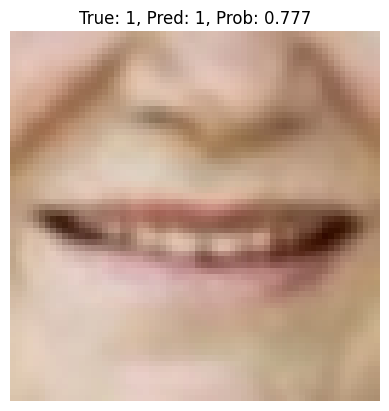

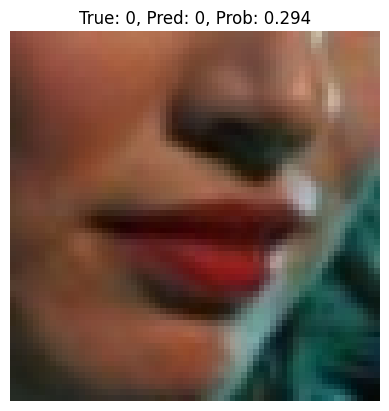

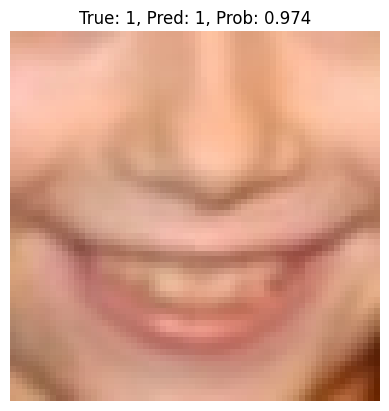

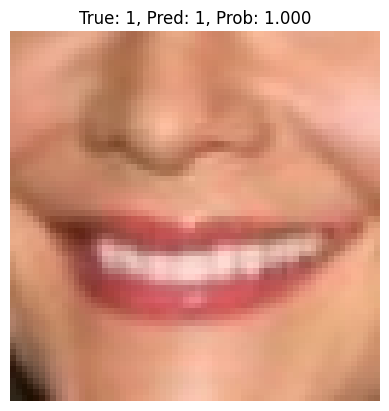

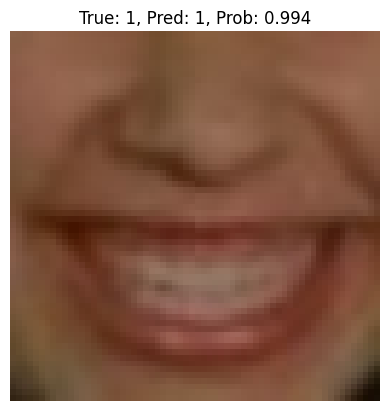

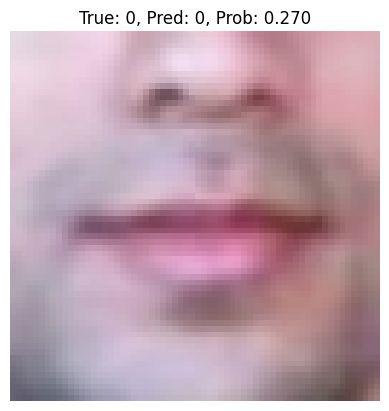

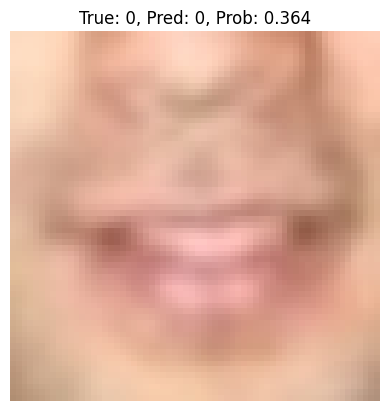

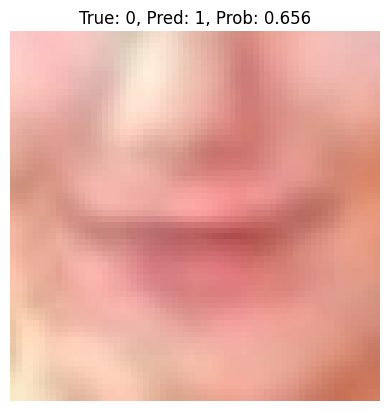

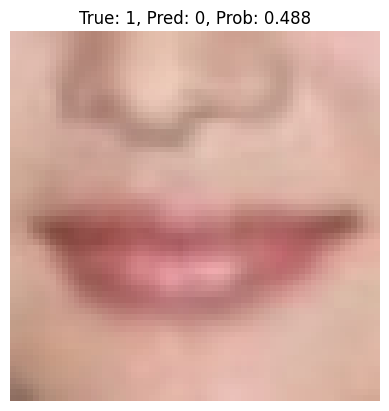

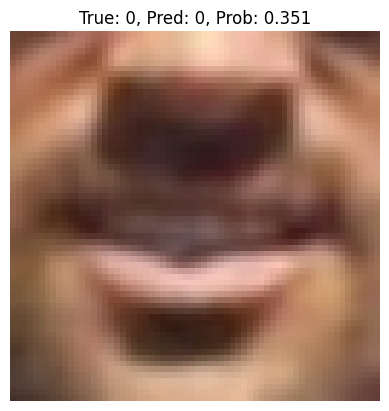

In [21]:
# Make classification on n=10 samples from the test set with image plot
model.eval()
n = 10
with torch.no_grad():
    for i, (images, labels) in enumerate(test_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images).squeeze(1)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= 0.5).float()

        for j in range(min(n, images.size(0))):
            img = images[j].cpu().permute(1, 2, 0).numpy() * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            plt.imshow(np.clip(img, 0, 1))
            plt.title(f"True: {labels[j].item():.0f}, Pred: {preds[j].item():.0f}, Prob: {probs[j].item():.3f}")
            plt.axis('off')
            plt.show()
        break